# 05. Análisis direccional del oleaje

Este notebook analiza la dirección de procedencia del oleaje registrada por las cuatro boyas incluidas en el archivo procesado `dataset_principal_oleaje.csv`.

El objetivo es identificar los sectores direccionales predominantes y estudiar qué valores de altura significativa de ola, Hs, están asociados a cada sector.

La dirección registrada por una boya representa las condiciones observadas en la ubicación del sensor. No debe interpretarse directamente como la dirección o intensidad del oleaje dentro de una dársena portuaria, ya que para ello sería necesario incorporar información adicional sobre batimetría, orientación de las bocanas, propagación del oleaje y agitación interior.

## Objetivos del notebook

1. Cargar y comprobar el dataset principal de oleaje.
2. Analizar la cobertura y calidad de la dirección media del oleaje.
3. Normalizar los valores direccionales al intervalo de 0° a 360°.
4. Clasificar las direcciones en sectores.
5. Calcular la frecuencia de observaciones por sector.
6. Calcular Hs media, mediana, P90, P95 y máxima por sector.
7. Identificar los sectores dominantes y los asociados a oleaje elevado.
8. Crear representaciones direccionales y rosas de oleaje.
9. Interpretar los resultados desde la perspectiva de la gestión portuaria.

Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import shutil

from pathlib import Path

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)
pd.set_option(
    "display.float_format",
    lambda x: f"{x:,.2f}"
)

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [2]:
print("Archivos CSV disponibles:")

for archivo in os.listdir("/content"):
    if archivo.lower().endswith(".csv"):
        print("-", archivo)

Archivos CSV disponibles:
- dataset_principal_oleaje.csv


In [3]:
RUTA_DATASET = Path(
    "/content/dataset_principal_oleaje.csv"
)

dataset_principal_oleaje = pd.read_csv(
    RUTA_DATASET,
    parse_dates=["fecha"]
)

print("Dataset cargado correctamente.")
print("Archivo:", RUTA_DATASET.name)

print(
    "Número de registros:",
    f"{len(dataset_principal_oleaje):,}"
)

print(
    "Número de columnas:",
    dataset_principal_oleaje.shape[1]
)

Dataset cargado correctamente.
Archivo: dataset_principal_oleaje.csv
Número de registros: 532,760
Número de columnas: 14


In [4]:
display(
    dataset_principal_oleaje.head()
)

,fecha,codigo_boya,nombre_boya,zona,tipo_red,tipo_boya,Hs_m,H1_3_m,Hmax_m,Tm02_s,Tp_s,dir_media_oleaje_grados,dir_pico_oleaje_grados,dispersion_pico_grados
0,2005-01-01 00:00:00,"1,103.00",Bilbao costera,Bilbao,Red costera,Costera,1.70,1.61,2.36,7.99,11.71,329.00,326.00,31.00
1,2005-01-01 01:00:00,"1,103.00",Bilbao costera,Bilbao,Red costera,Costera,2.03,1.89,2.94,8.44,11.70,328.00,326.00,40.00
2,2005-01-01 02:00:00,"1,103.00",Bilbao costera,Bilbao,Red costera,Costera,1.87,1.77,2.54,8.39,11.76,327.00,326.00,36.00
3,2005-01-01 03:00:00,"1,103.00",Bilbao costera,Bilbao,Red costera,Costera,2.04,1.92,2.72,8.71,12.48,329.00,333.00,36.00
4,2005-01-01 04:00:00,"1,103.00",Bilbao costera,Bilbao,Red costera,Costera,1.92,1.82,2.59,8.60,11.79,324.00,325.00,45.00


In [5]:
variables_necesarias = [
    "fecha",
    "codigo_boya",
    "nombre_boya",
    "tipo_boya",
    "Hs_m",
    "dir_media_oleaje_grados",
    "dir_pico_oleaje_grados"
]

print("COMPROBACIÓN DE VARIABLES")
print("-" * 50)

for variable in variables_necesarias:

    if variable in dataset_principal_oleaje.columns:
        print(variable, ": disponible")

    else:
        print(variable, ": NO disponible")

COMPROBACIÓN DE VARIABLES
--------------------------------------------------
fecha : disponible
codigo_boya : disponible
nombre_boya : disponible
tipo_boya : disponible
Hs_m : disponible
dir_media_oleaje_grados : disponible
dir_pico_oleaje_grados : disponible


Creación de carpetas de salida

In [6]:
FIGURES_DIR = Path(
    "/content/figures"
)

TABLES_DIR = Path(
    "/content/tables"
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

TABLES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Carpeta de figuras:", FIGURES_DIR)
print("Carpeta de tablas:", TABLES_DIR)

Carpeta de figuras: /content/figures
Carpeta de tablas: /content/tables


Control de calidad de la dirección

Se crea copia de trabajo

In [7]:
datos_direccionales = (
    dataset_principal_oleaje.copy()
)

datos_direccionales = (
    datos_direccionales
    .sort_values(
        [
            "codigo_boya",
            "fecha"
        ]
    )
    .reset_index(drop=True)
)

print("Copia de trabajo creada.")

print(
    "Número de registros:",
    f"{len(datos_direccionales):,}"
)

Copia de trabajo creada.
Número de registros: 532,760


Se calcula la cobertura direccional por boya

In [8]:
tabla_calidad_direccion = (
    datos_direccionales
    .groupby(
        [
            "codigo_boya",
            "nombre_boya",
            "tipo_boya"
        ],
        as_index=False
    )
    .agg(
        registros_totales=(
            "fecha",
            "size"
        ),
        direccion_media_valida=(
            "dir_media_oleaje_grados",
            "count"
        ),
        direccion_pico_valida=(
            "dir_pico_oleaje_grados",
            "count"
        )
    )
)

tabla_calidad_direccion[
    "pct_direccion_media_valida"
] = (
    tabla_calidad_direccion[
        "direccion_media_valida"
    ]
    / tabla_calidad_direccion[
        "registros_totales"
    ]
    * 100
).round(2)

tabla_calidad_direccion[
    "pct_direccion_pico_valida"
] = (
    tabla_calidad_direccion[
        "direccion_pico_valida"
    ]
    / tabla_calidad_direccion[
        "registros_totales"
    ]
    * 100
).round(2)

display(tabla_calidad_direccion)

,codigo_boya,nombre_boya,tipo_boya,registros_totales,direccion_media_valida,direccion_pico_valida,pct_direccion_media_valida,pct_direccion_pico_valida
0,"1,103.00",Bilbao costera,Costera,140991,134118,133818,95.13,94.91
1,"1,117.00",Gijón costera,Costera,150719,150714,150369,100.00,99.77
2,"2,136.00",Bilbao-Vizcaya,Exterior,162793,160600,160600,98.65,98.65
3,"2,242.00",Cabo de Peñas,Exterior,78256,78253,78253,100.00,100.00


Se guarda la tabla de calidad

In [10]:
ruta_calidad_direccion = (
    TABLES_DIR /
    "tabla_calidad_direccion_oleaje.csv"
)

tabla_calidad_direccion.to_csv(
    ruta_calidad_direccion,
    index=False,
    encoding="utf-8-sig"
)

print("Tabla guardada correctamente:")
print(ruta_calidad_direccion)

Tabla guardada correctamente:
/content/tables/tabla_calidad_direccion_oleaje.csv


Se comprueba el rango de direcciones que debe de estar entre 0ª y 360ª

In [11]:
resumen_rango_direccion = (
    datos_direccionales
    .groupby(
        [
            "codigo_boya",
            "nombre_boya"
        ],
        as_index=False
    )
    .agg(
        direccion_media_minima=(
            "dir_media_oleaje_grados",
            "min"
        ),
        direccion_media_maxima=(
            "dir_media_oleaje_grados",
            "max"
        ),
        direccion_pico_minima=(
            "dir_pico_oleaje_grados",
            "min"
        ),
        direccion_pico_maxima=(
            "dir_pico_oleaje_grados",
            "max"
        )
    )
)

display(resumen_rango_direccion)

,codigo_boya,nombre_boya,direccion_media_minima,direccion_media_maxima,direccion_pico_minima,direccion_pico_maxima
0,"1,103.00",Bilbao costera,0.00,360.00,0.00,360.00
1,"1,117.00",Gijón costera,0.00,360.00,0.00,360.00
2,"2,136.00",Bilbao-Vizcaya,0.00,360.00,0.00,360.00
3,"2,242.00",Cabo de Peñas,0.00,360.00,0.00,360.00


Detección de valores fuera del intervalo

In [12]:
direccion_media_fuera_rango = (
    datos_direccionales[
        "dir_media_oleaje_grados"
    ].notna()
    & (
        (
            datos_direccionales[
                "dir_media_oleaje_grados"
            ] < 0
        )
        | (
            datos_direccionales[
                "dir_media_oleaje_grados"
            ] > 360
        )
    )
)

direccion_pico_fuera_rango = (
    datos_direccionales[
        "dir_pico_oleaje_grados"
    ].notna()
    & (
        (
            datos_direccionales[
                "dir_pico_oleaje_grados"
            ] < 0
        )
        | (
            datos_direccionales[
                "dir_pico_oleaje_grados"
            ] > 360
        )
    )
)

print(
    "Direcciones medias fuera de rango:",
    direccion_media_fuera_rango.sum()
)

print(
    "Direcciones de pico fuera de rango:",
    direccion_pico_fuera_rango.sum()
)

Direcciones medias fuera de rango: 0
Direcciones de pico fuera de rango: 0


Normalización de las direcciones del oleaje

El valor de 360 pasa a 0

In [13]:
datos_direccionales[
    "direccion_media_normalizada"
] = (
    datos_direccionales[
        "dir_media_oleaje_grados"
    ]
    % 360
)

datos_direccionales[
    "direccion_pico_normalizada"
] = (
    datos_direccionales[
        "dir_pico_oleaje_grados"
    ]
    % 360
)

display(
    datos_direccionales[
        [
            "dir_media_oleaje_grados",
            "direccion_media_normalizada",
            "dir_pico_oleaje_grados",
            "direccion_pico_normalizada"
        ]
    ].head(10)
)

,dir_media_oleaje_grados,direccion_media_normalizada,dir_pico_oleaje_grados,direccion_pico_normalizada
0,329.00,329.00,326.00,326.00
1,328.00,328.00,326.00,326.00
2,327.00,327.00,326.00,326.00
3,329.00,329.00,333.00,333.00
4,324.00,324.00,325.00,325.00
5,325.00,325.00,328.00,328.00
6,324.00,324.00,319.00,319.00
7,324.00,324.00,321.00,321.00
8,324.00,324.00,318.00,318.00
9,329.00,329.00,330.00,330.00


In [14]:
print(
    "Mínimo de dirección media normalizada:",
    datos_direccionales[
        "direccion_media_normalizada"
    ].min()
)

print(
    "Máximo de dirección media normalizada:",
    datos_direccionales[
        "direccion_media_normalizada"
    ].max()
)

print(
    "Mínimo de dirección de pico normalizada:",
    datos_direccionales[
        "direccion_pico_normalizada"
    ].min()
)

print(
    "Máximo de dirección de pico normalizada:",
    datos_direccionales[
        "direccion_pico_normalizada"
    ].max()
)

Mínimo de dirección media normalizada: 0.0
Máximo de dirección media normalizada: 359.0
Mínimo de dirección de pico normalizada: 0.0
Máximo de dirección de pico normalizada: 359.0


### Control de calidad de las variables direccionales

Antes de clasificar las direcciones en sectores, se revisó la cobertura y el intervalo de valores de las variables direccionales.

La dirección media del oleaje presenta una cobertura elevada en las cuatro boyas, aunque existen algunos registros sin información direccional. Estos valores ausentes no se imputan, ya que una asignación artificial podría modificar la distribución de procedencias.

Los valores válidos se normalizan al intervalo comprendido entre 0° y menos de 360°. El valor 360° se transforma en 0°, puesto que ambos representan la dirección norte.

El análisis direccional posterior se realizará únicamente con registros que dispongan simultáneamente de una dirección válida y un valor válido de Hs.

Creación de sectores bidireccionales

Definición del orden de los sectores

In [16]:
orden_sectores = [
    "N",
    "NE",
    "E",
    "SE",
    "S",
    "SO",
    "O",
    "NO"
]

centros_sectores_grados = {
    "N": 0,
    "NE": 45,
    "E": 90,
    "SE": 135,
    "S": 180,
    "SO": 225,
    "O": 270,
    "NO": 315
}

print("Sectores definidos:", orden_sectores)

Sectores definidos: ['N', 'NE', 'E', 'SE', 'S', 'SO', 'O', 'NO']


Creación de la función de clasificaión para sectores

In [17]:
def clasificar_sector(direccion):

    if pd.isna(direccion):
        return np.nan

    direccion = direccion % 360

    if direccion >= 337.5 or direccion < 22.5:
        return "N"

    elif direccion < 67.5:
        return "NE"

    elif direccion < 112.5:
        return "E"

    elif direccion < 157.5:
        return "SE"

    elif direccion < 202.5:
        return "S"

    elif direccion < 247.5:
        return "SO"

    elif direccion < 292.5:
        return "O"

    else:
        return "NO"


print("Función clasificar_sector definida correctamente.")

Función clasificar_sector definida correctamente.


In [18]:
datos_direccionales[
    "sector_direccion_media"
] = (
    datos_direccionales[
        "direccion_media_normalizada"
    ]
    .apply(clasificar_sector)
)

datos_direccionales[
    "sector_direccion_pico"
] = (
    datos_direccionales[
        "direccion_pico_normalizada"
    ]
    .apply(clasificar_sector)
)

datos_direccionales[
    "sector_direccion_media"
] = pd.Categorical(
    datos_direccionales[
        "sector_direccion_media"
    ],
    categories=orden_sectores,
    ordered=True
)

datos_direccionales[
    "sector_direccion_pico"
] = pd.Categorical(
    datos_direccionales[
        "sector_direccion_pico"
    ],
    categories=orden_sectores,
    ordered=True
)

display(
    datos_direccionales[
        [
            "direccion_media_normalizada",
            "sector_direccion_media",
            "direccion_pico_normalizada",
            "sector_direccion_pico"
        ]
    ].head(15)
)

,direccion_media_normalizada,sector_direccion_media,direccion_pico_normalizada,sector_direccion_pico
0,329.00,NO,326.00,NO
1,328.00,NO,326.00,NO
2,327.00,NO,326.00,NO
3,329.00,NO,333.00,NO
4,324.00,NO,325.00,NO
5,325.00,NO,328.00,NO
6,324.00,NO,319.00,NO
7,324.00,NO,321.00,NO
8,324.00,NO,318.00,NO
9,329.00,NO,330.00,NO


Comprobación clasificación de referencia

In [19]:
direcciones_prueba = pd.DataFrame(
    {
        "direccion_grados": [
            0,
            22,
            45,
            90,
            135,
            180,
            225,
            270,
            315,
            359
        ]
    }
)

direcciones_prueba["sector"] = (
    direcciones_prueba[
        "direccion_grados"
    ]
    .apply(clasificar_sector)
)

display(direcciones_prueba)

,direccion_grados,sector
0,0,N
1,22,N
2,45,NE
3,90,E
4,135,SE
5,180,S
6,225,SO
7,270,O
8,315,NO
9,359,N


Creación de dataset válido para análisis de direcciones

In [22]:
datos_direccion_validos = (
    datos_direccionales[
        datos_direccionales[
            "Hs_m"
        ].notna()
        &
        datos_direccionales[
            "sector_direccion_media"
        ].notna()
    ]
    .copy()
)

print(
    "Registros direccionales válidos:",
    f"{len(datos_direccion_validos):,}"
)

print(
    "Porcentaje sobre el dataset:",
    round(
        len(datos_direccion_validos)
        / len(datos_direccionales)
        * 100,
        2
    )
)

Registros direccionales válidos: 523,681
Porcentaje sobre el dataset: 98.3


Frecuencia por sector

## 2. Frecuencia de procedencia del oleaje

La frecuencia direccional representa la proporción de observaciones válidas que procede de cada sector.

El porcentaje se calcula de forma independiente para cada boya. De este modo, la suma de los ocho sectores de cada estación es aproximadamente igual al 100 %.

El sector más frecuente se interpreta como la procedencia dominante observada.

Cálculo de frecuencias

In [23]:
tabla_frecuencia_direccional = (
    datos_direccion_validos
    .groupby(
        [
            "codigo_boya",
            "nombre_boya",
            "tipo_boya",
            "sector_direccion_media"
        ],
        observed=True,
        as_index=False
    )
    .agg(
        observaciones=(
            "Hs_m",
            "count"
        )
    )
)

tabla_frecuencia_direccional[
    "total_boya"
] = (
    tabla_frecuencia_direccional
    .groupby("codigo_boya")[
        "observaciones"
    ]
    .transform("sum")
)

tabla_frecuencia_direccional[
    "frecuencia_pct"
] = (
    tabla_frecuencia_direccional[
        "observaciones"
    ]
    / tabla_frecuencia_direccional[
        "total_boya"
    ]
    * 100
).round(2)

tabla_frecuencia_direccional = (
    tabla_frecuencia_direccional
    .sort_values(
        [
            "codigo_boya",
            "sector_direccion_media"
        ]
    )
    .reset_index(drop=True)
)

display(tabla_frecuencia_direccional.head(16))

,codigo_boya,nombre_boya,tipo_boya,sector_direccion_media,observaciones,total_boya,frecuencia_pct
0,"1,103.00",Bilbao costera,Costera,N,28109,134118,20.96
1,"1,103.00",Bilbao costera,Costera,NE,2375,134118,1.77
2,"1,103.00",Bilbao costera,Costera,E,172,134118,0.13
3,"1,103.00",Bilbao costera,Costera,SE,161,134118,0.12
4,"1,103.00",Bilbao costera,Costera,S,237,134118,0.18
5,"1,103.00",Bilbao costera,Costera,SO,354,134118,0.26
6,"1,103.00",Bilbao costera,Costera,O,846,134118,0.63
7,"1,103.00",Bilbao costera,Costera,NO,101864,134118,75.95
8,"1,117.00",Gijón costera,Costera,N,46799,150714,31.05
9,"1,117.00",Gijón costera,Costera,NE,15952,150714,10.58


Comprobación suma de porcentajes

In [24]:
comprobacion_porcentajes = (
    tabla_frecuencia_direccional
    .groupby(
        [
            "codigo_boya",
            "nombre_boya"
        ],
        as_index=False
    )
    .agg(
        suma_porcentajes=(
            "frecuencia_pct",
            "sum"
        )
    )
)

display(comprobacion_porcentajes)

,codigo_boya,nombre_boya,suma_porcentajes
0,"1,103.00",Bilbao costera,100.00
1,"1,117.00",Gijón costera,99.98
2,"2,136.00",Bilbao-Vizcaya,100.00
3,"2,242.00",Cabo de Peñas,100.00


Se guarda la tabla

In [25]:
ruta_frecuencia_direccional = (
    TABLES_DIR /
    "tabla_frecuencia_direccional.csv"
)

tabla_frecuencia_direccional.to_csv(
    ruta_frecuencia_direccional,
    index=False,
    encoding="utf-8-sig"
)

print("Tabla guardada:")
print(ruta_frecuencia_direccional)

Tabla guardada:
/content/tables/tabla_frecuencia_direccional.csv


Se grafican las frecuencias por sector

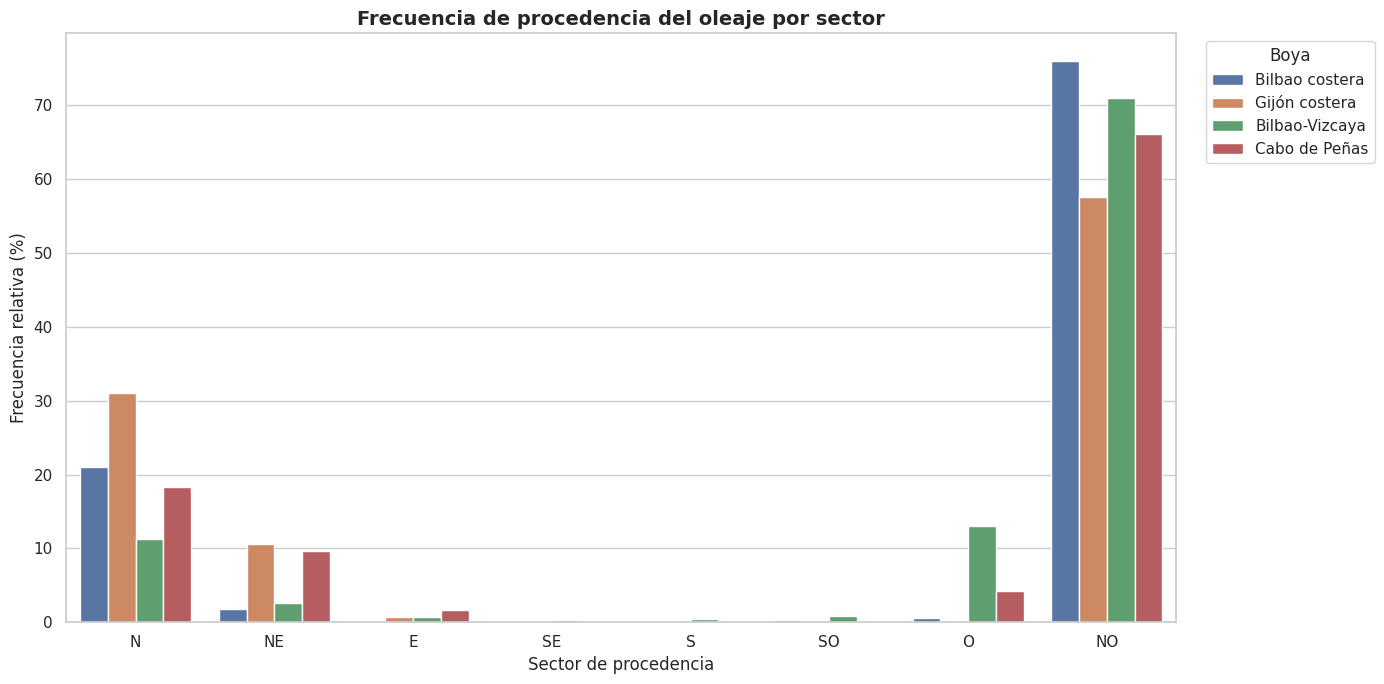

Figura guardada:
/content/figures/frecuencia_direccion_por_boya.png


In [26]:
plt.figure(figsize=(14, 7))

sns.barplot(
    data=tabla_frecuencia_direccional,
    x="sector_direccion_media",
    y="frecuencia_pct",
    hue="nombre_boya",
    order=orden_sectores
)

plt.title(
    "Frecuencia de procedencia del oleaje por sector",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Sector de procedencia")
plt.ylabel("Frecuencia relativa (%)")

plt.legend(
    title="Boya",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

ruta_frecuencia_figura = (
    FIGURES_DIR /
    "frecuencia_direccion_por_boya.png"
)

plt.savefig(
    ruta_frecuencia_figura,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figura guardada:")
print(ruta_frecuencia_figura)

Estudio Hs por sector

## 3. Altura significativa del oleaje por sector

La frecuencia de un sector no indica necesariamente que ese sector esté asociado a los mayores valores de Hs.

Por este motivo, para cada boya y sector se calculan:

- Hs media;
- Hs mediana;
- percentil 90;
- percentil 95;
- Hs máxima.

El análisis permite diferenciar entre el sector más frecuente y el sector asociado a condiciones de oleaje más elevadas.

In [27]:
tabla_hs_por_sector = (
    datos_direccion_validos
    .groupby(
        [
            "codigo_boya",
            "nombre_boya",
            "tipo_boya",
            "sector_direccion_media"
        ],
        observed=True,
        as_index=False
    )
    .agg(
        observaciones=(
            "Hs_m",
            "count"
        ),
        Hs_media_m=(
            "Hs_m",
            "mean"
        ),
        Hs_mediana_m=(
            "Hs_m",
            "median"
        ),
        Hs_p90_m=(
            "Hs_m",
            lambda valores:
            valores.quantile(0.90)
        ),
        Hs_p95_m=(
            "Hs_m",
            lambda valores:
            valores.quantile(0.95)
        ),
        Hs_maxima_m=(
            "Hs_m",
            "max"
        )
    )
)

columnas_hs_sector = [
    "Hs_media_m",
    "Hs_mediana_m",
    "Hs_p90_m",
    "Hs_p95_m",
    "Hs_maxima_m"
]

tabla_hs_por_sector[
    columnas_hs_sector
] = (
    tabla_hs_por_sector[
        columnas_hs_sector
    ]
    .round(2)
)

tabla_hs_por_sector = (
    tabla_hs_por_sector
    .sort_values(
        [
            "codigo_boya",
            "sector_direccion_media"
        ]
    )
    .reset_index(drop=True)
)

display(tabla_hs_por_sector.head(16))

,codigo_boya,nombre_boya,tipo_boya,sector_direccion_media,observaciones,Hs_media_m,Hs_mediana_m,Hs_p90_m,Hs_p95_m,Hs_maxima_m
0,"1,103.00",Bilbao costera,Costera,N,28109,1.14,0.95,1.96,2.45,8.37
1,"1,103.00",Bilbao costera,Costera,NE,2375,0.86,0.81,1.31,1.53,2.29
2,"1,103.00",Bilbao costera,Costera,E,172,0.57,0.58,0.75,0.81,0.95
3,"1,103.00",Bilbao costera,Costera,SE,161,0.55,0.57,0.77,0.81,0.98
4,"1,103.00",Bilbao costera,Costera,S,237,0.60,0.58,0.83,0.96,1.18
5,"1,103.00",Bilbao costera,Costera,SO,354,0.68,0.67,0.94,1.06,1.52
6,"1,103.00",Bilbao costera,Costera,O,846,0.80,0.77,1.18,1.37,2.21
7,"1,103.00",Bilbao costera,Costera,NO,101864,1.53,1.32,2.71,3.25,8.19
8,"1,117.00",Gijón costera,Costera,N,46799,1.53,1.29,2.67,3.40,8.98
9,"1,117.00",Gijón costera,Costera,NE,15952,1.38,1.28,2.19,2.52,5.10


In [28]:
ruta_hs_sector = (
    TABLES_DIR /
    "tabla_hs_por_sector_direccional.csv"
)

tabla_hs_por_sector.to_csv(
    ruta_hs_sector,
    index=False,
    encoding="utf-8-sig"
)

print("Tabla guardada:")
print(ruta_hs_sector)

Tabla guardada:
/content/tables/tabla_hs_por_sector_direccional.csv


Crear tabla percentiles P95

In [29]:
tabla_percentil95_direccion = (
    tabla_hs_por_sector[
        [
            "codigo_boya",
            "nombre_boya",
            "tipo_boya",
            "sector_direccion_media",
            "observaciones",
            "Hs_p95_m"
        ]
    ]
    .copy()
)

tabla_percentil95_direccion.to_csv(
    TABLES_DIR /
    "tabla_percentil95_por_direccion.csv",
    index=False,
    encoding="utf-8-sig"
)

display(tabla_percentil95_direccion.head())

,codigo_boya,nombre_boya,tipo_boya,sector_direccion_media,observaciones,Hs_p95_m
0,"1,103.00",Bilbao costera,Costera,N,28109,2.45
1,"1,103.00",Bilbao costera,Costera,NE,2375,1.53
2,"1,103.00",Bilbao costera,Costera,E,172,0.81
3,"1,103.00",Bilbao costera,Costera,SE,161,0.81
4,"1,103.00",Bilbao costera,Costera,S,237,0.96


Gráfico Hs media por sector

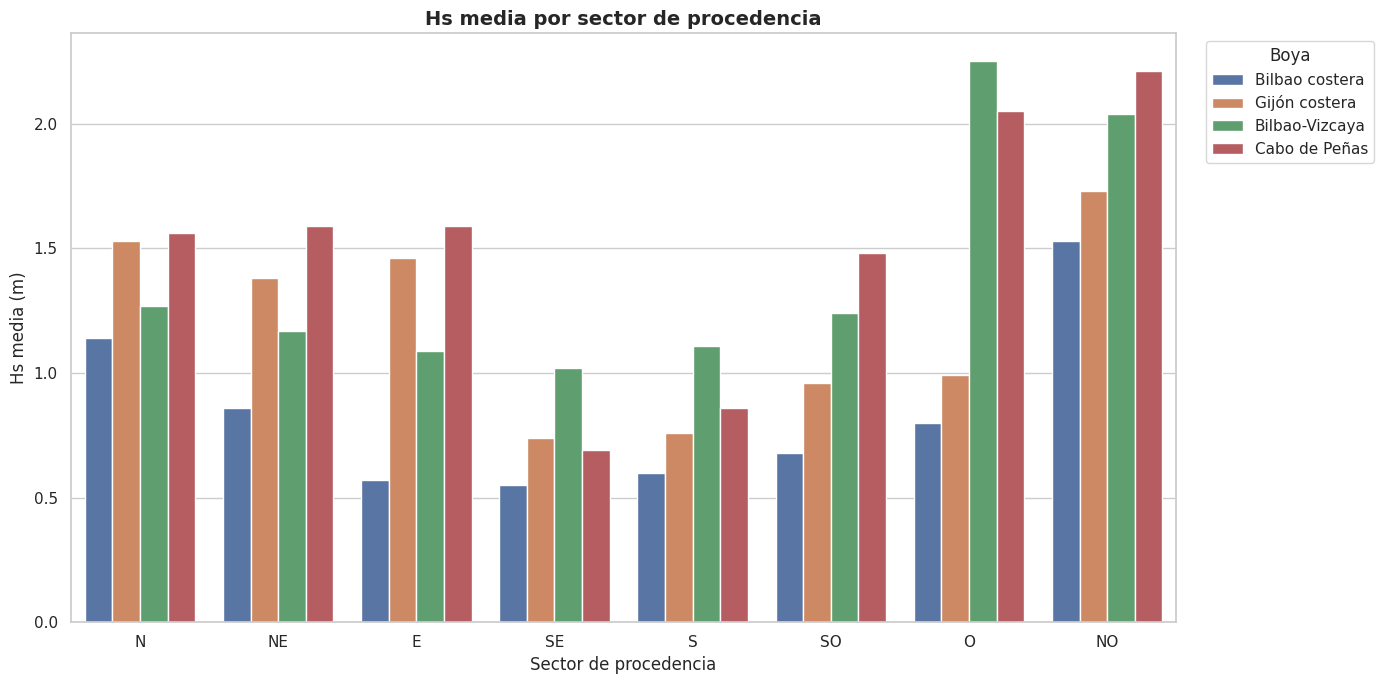

Figura guardada:
/content/figures/hs_media_por_sector_direccional.png


In [30]:
plt.figure(figsize=(14, 7))

sns.barplot(
    data=tabla_hs_por_sector,
    x="sector_direccion_media",
    y="Hs_media_m",
    hue="nombre_boya",
    order=orden_sectores
)

plt.title(
    "Hs media por sector de procedencia",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Sector de procedencia")
plt.ylabel("Hs media (m)")

plt.legend(
    title="Boya",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

ruta_hs_media_sector = (
    FIGURES_DIR /
    "hs_media_por_sector_direccional.png"
)

plt.savefig(
    ruta_hs_media_sector,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figura guardada:")
print(ruta_hs_media_sector)

Gráfico P95 por sector

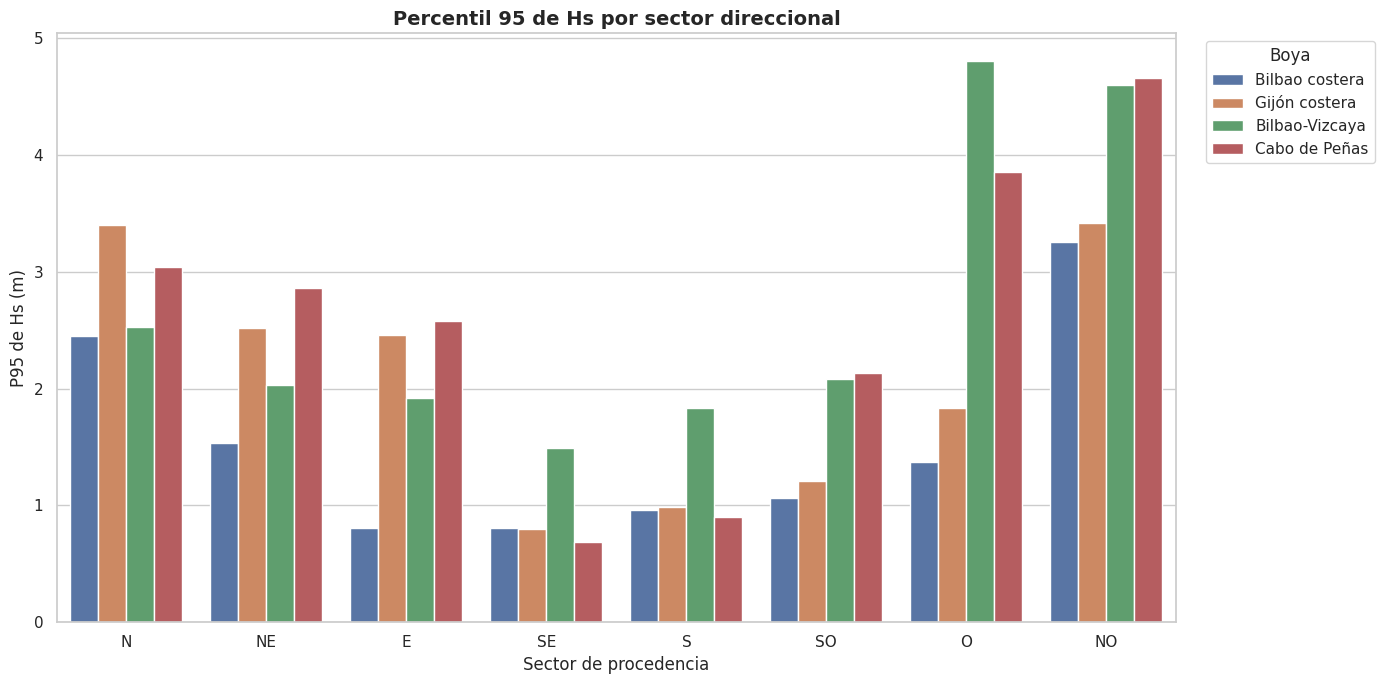

Figura guardada:
/content/figures/percentil95_hs_por_sector.png


In [31]:
plt.figure(figsize=(14, 7))

sns.barplot(
    data=tabla_hs_por_sector,
    x="sector_direccion_media",
    y="Hs_p95_m",
    hue="nombre_boya",
    order=orden_sectores
)

plt.title(
    "Percentil 95 de Hs por sector direccional",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Sector de procedencia")
plt.ylabel("P95 de Hs (m)")

plt.legend(
    title="Boya",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

ruta_p95_sector = (
    FIGURES_DIR /
    "percentil95_hs_por_sector.png"
)

plt.savefig(
    ruta_p95_sector,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figura guardada:")
print(ruta_p95_sector)

SECTORES DOMINANTES

Identificación del sector más frecuente

In [32]:
indices_sector_frecuente = (
    tabla_frecuencia_direccional
    .groupby("codigo_boya")[
        "frecuencia_pct"
    ]
    .idxmax()
)

sectores_mas_frecuentes = (
    tabla_frecuencia_direccional
    .loc[
        indices_sector_frecuente,
        [
            "codigo_boya",
            "nombre_boya",
            "tipo_boya",
            "sector_direccion_media",
            "observaciones",
            "frecuencia_pct"
        ]
    ]
    .rename(
        columns={
            "sector_direccion_media":
            "sector_mas_frecuente",
            "observaciones":
            "observaciones_sector_frecuente",
            "frecuencia_pct":
            "frecuencia_sector_pct"
        }
    )
    .reset_index(drop=True)
)

display(sectores_mas_

_IncompleteInputError: incomplete input (2254905344.py, line 35)

Identificación del sector con mayor Hs media

In [33]:
indices_mayor_hs_media = (
    tabla_hs_por_sector
    .groupby("codigo_boya")[
        "Hs_media_m"
    ]
    .idxmax()
)

sectores_mayor_hs_media = (
    tabla_hs_por_sector
    .loc[
        indices_mayor_hs_media,
        [
            "codigo_boya",
            "sector_direccion_media",
            "Hs_media_m"
        ]
    ]
    .rename(
        columns={
            "sector_direccion_media":
            "sector_mayor_Hs_media",
            "Hs_media_m":
            "mayor_Hs_media_m"
        }
    )
    .reset_index(drop=True)
)

display(sectores_mayor_hs_media)

,codigo_boya,sector_mayor_Hs_media,mayor_Hs_media_m
0,"1,103.00",NO,1.53
1,"1,117.00",NO,1.73
2,"2,136.00",O,2.25
3,"2,242.00",NO,2.21


Identificar el sector con mayor P95

In [34]:
indices_mayor_p95 = (
    tabla_hs_por_sector
    .groupby("codigo_boya")[
        "Hs_p95_m"
    ]
    .idxmax()
)

sectores_mayor_p95 = (
    tabla_hs_por_sector
    .loc[
        indices_mayor_p95,
        [
            "codigo_boya",
            "sector_direccion_media",
            "Hs_p95_m"
        ]
    ]
    .rename(
        columns={
            "sector_direccion_media":
            "sector_mayor_P95",
            "Hs_p95_m":
            "mayor_P95_m"
        }
    )
    .reset_index(drop=True)
)

display(sectores_mayor_p95)

,codigo_boya,sector_mayor_P95,mayor_P95_m
0,"1,103.00",NO,3.25
1,"1,117.00",NO,3.42
2,"2,136.00",O,4.80
3,"2,242.00",NO,4.66


Creación de tabla de sectores dominantes

In [35]:
indices_mayor_p95 = (
    tabla_hs_por_sector
    .groupby("codigo_boya")[
        "Hs_p95_m"
    ]
    .idxmax()
)

sectores_mayor_p95 = (
    tabla_hs_por_sector
    .loc[
        indices_mayor_p95,
        [
            "codigo_boya",
            "sector_direccion_media",
            "Hs_p95_m"
        ]
    ]
    .rename(
        columns={
            "sector_direccion_media":
            "sector_mayor_P95",
            "Hs_p95_m":
            "mayor_P95_m"
        }
    )
    .reset_index(drop=True)
)

display(sectores_mayor_p95)

,codigo_boya,sector_mayor_P95,mayor_P95_m
0,"1,103.00",NO,3.25
1,"1,117.00",NO,3.42
2,"2,136.00",O,4.80
3,"2,242.00",NO,4.66


Guardar los sectores dominantes

In [40]:
indices_sector_frecuente = (
    tabla_frecuencia_direccional
    .groupby("codigo_boya")[
        "frecuencia_pct"
    ]
    .idxmax()
)

sectores_mas_frecuentes = (
    tabla_frecuencia_direccional
    .loc[
        indices_sector_frecuente,
        [
            "codigo_boya",
            "nombre_boya",
            "tipo_boya",
            "sector_direccion_media",
            "observaciones",
            "frecuencia_pct"
        ]
    ]
    .rename(
        columns={
            "sector_direccion_media":
            "sector_mas_frecuente",
            "observaciones":
            "observaciones_sector_frecuente",
            "frecuencia_pct":
            "frecuencia_sector_pct"
        }
    )
    .reset_index(drop=True)
)

tabla_sectores_dominantes = (
    sectores_mas_frecuentes
    .merge(
        sectores_mayor_hs_media,
        on="codigo_boya",
        how="left"
    )
    .merge(
        sectores_mayor_p95,
        on="codigo_boya",
        how="left"
    )
)

ruta_sectores_dominantes = (
    TABLES_DIR /
    "tabla_sectores_dominantes.csv"
)

tabla_sectores_dominantes.to_csv(
    ruta_sectores_dominantes,
    index=False,
    encoding="utf-8-sig"
)

print("Tabla guardada:")
print(ruta_sectores_dominantes)


Tabla guardada:
/content/tables/tabla_sectores_dominantes.csv


DIRECCIÓN EN CONDICIONES DE Hs ELEVADA

## 4. Dirección del oleaje en condiciones elevadas

Para analizar los sectores asociados a condiciones potencialmente adversas, se seleccionan los registros con Hs igual o superior a 3 m.

Este umbral tiene carácter exploratorio y permite estudiar si las condiciones elevadas se concentran en sectores direccionales concretos.

El resultado no constituye un criterio oficial de operatividad portuaria.

Se seleccionan registros con Hs igual o superior a 3m

In [41]:
datos_hs_elevada = (
    datos_direccion_validos[
        datos_direccion_validos["Hs_m"] >= 3
    ]
    .copy()
)

print(
    "Registros con Hs ≥ 3 m:",
    f"{len(datos_hs_elevada):,}"
)

print(
    "Porcentaje sobre registros direccionales:",
    round(
        len(datos_hs_elevada)
        / len(datos_direccion_validos)
        * 100,
        2
    ),
    "%"
)

Registros con Hs ≥ 3 m: 58,131
Porcentaje sobre registros direccionales: 11.1 %


Se calcula la frecuencia direccional para Hs elevada

In [42]:
tabla_direccion_hs_elevada = (
    datos_hs_elevada
    .groupby(
        [
            "codigo_boya",
            "nombre_boya",
            "tipo_boya",
            "sector_direccion_media"
        ],
        observed=True,
        as_index=False
    )
    .agg(
        observaciones_Hs_ge_3m=(
            "Hs_m",
            "count"
        ),
        Hs_media_m=(
            "Hs_m",
            "mean"
        ),
        Hs_maxima_m=(
            "Hs_m",
            "max"
        )
    )
)

tabla_direccion_hs_elevada[
    "total_Hs_ge_3m_boya"
] = (
    tabla_direccion_hs_elevada
    .groupby("codigo_boya")[
        "observaciones_Hs_ge_3m"
    ]
    .transform("sum")
)

tabla_direccion_hs_elevada[
    "frecuencia_Hs_ge_3m_pct"
] = (
    tabla_direccion_hs_elevada[
        "observaciones_Hs_ge_3m"
    ]
    / tabla_direccion_hs_elevada[
        "total_Hs_ge_3m_boya"
    ]
    * 100
).round(2)

tabla_direccion_hs_elevada[
    [
        "Hs_media_m",
        "Hs_maxima_m"
    ]
] = (
    tabla_direccion_hs_elevada[
        [
            "Hs_media_m",
            "Hs_maxima_m"
        ]
    ]
    .round(2)
)

display(tabla_direccion_hs_elevada.head(16))

,codigo_boya,nombre_boya,tipo_boya,sector_direccion_media,observaciones_Hs_ge_3m,Hs_media_m,Hs_maxima_m,total_Hs_ge_3m_boya,frecuencia_Hs_ge_3m_pct
0,"1,103.00",Bilbao costera,Costera,N,731,3.83,8.37,7719,9.47
1,"1,103.00",Bilbao costera,Costera,NO,6988,3.73,8.19,7719,90.53
2,"1,117.00",Gijón costera,Costera,N,3448,4.01,8.98,11694,29.49
3,"1,117.00",Gijón costera,Costera,NE,314,3.35,5.10,11694,2.69
4,"1,117.00",Gijón costera,Costera,E,18,3.52,3.99,11694,0.15
5,"1,117.00",Gijón costera,Costera,NO,7914,3.69,7.99,11694,67.68
6,"2,136.00",Bilbao-Vizcaya,Exterior,N,427,3.59,7.47,25848,1.65
7,"2,136.00",Bilbao-Vizcaya,Exterior,NE,21,3.69,5.28,25848,0.08
8,"2,136.00",Bilbao-Vizcaya,Exterior,E,3,3.26,3.27,25848,0.01
9,"2,136.00",Bilbao-Vizcaya,Exterior,SE,2,5.40,7.16,25848,0.01


Se guarda la tabla generada

In [43]:
ruta_direccion_hs_elevada = (
    TABLES_DIR /
    "tabla_direccion_hs_ge_3m.csv"
)

tabla_direccion_hs_elevada.to_csv(
    ruta_direccion_hs_elevada,
    index=False,
    encoding="utf-8-sig"
)

print("Tabla guardada:")
print(ruta_direccion_hs_elevada)

Tabla guardada:
/content/tables/tabla_direccion_hs_ge_3m.csv


Gráfico direccional para Hs igual o superior a 3 m

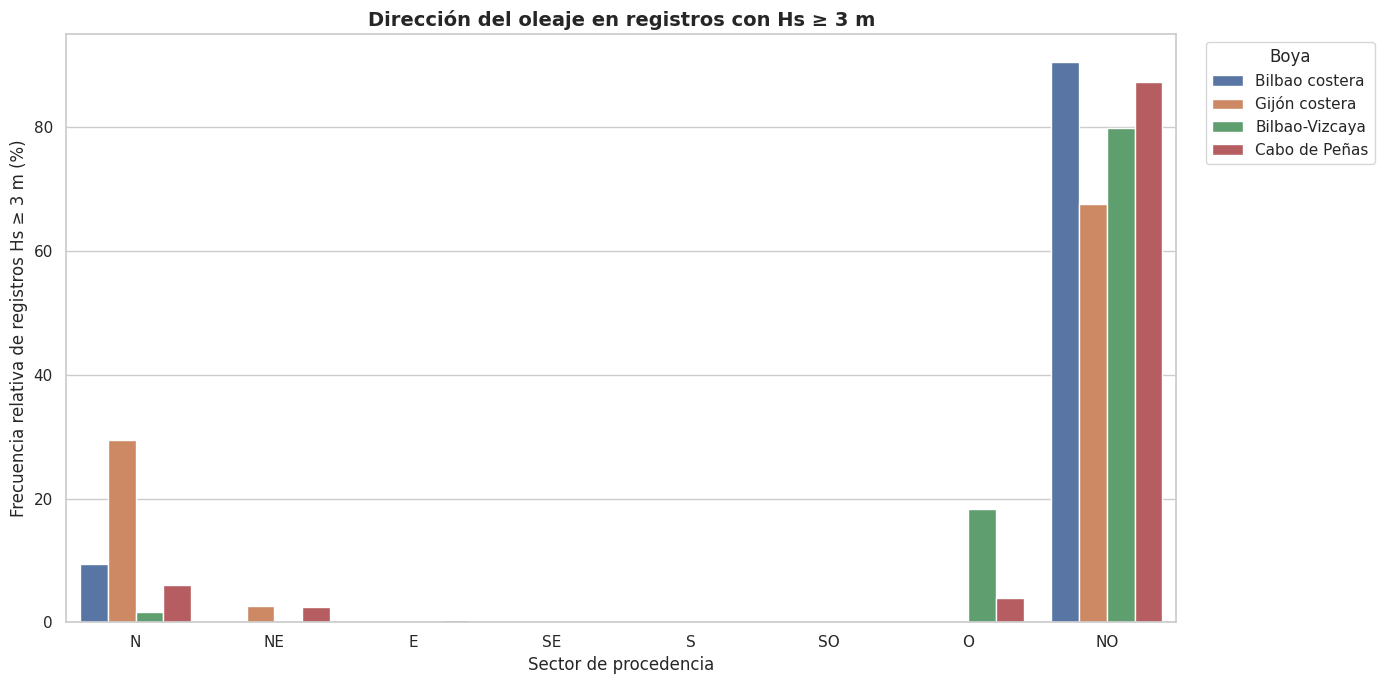

Figura guardada:
/content/figures/direccion_oleaje_hs_ge_3m.png


In [44]:
plt.figure(figsize=(14, 7))

sns.barplot(
    data=tabla_direccion_hs_elevada,
    x="sector_direccion_media",
    y="frecuencia_Hs_ge_3m_pct",
    hue="nombre_boya",
    order=orden_sectores
)

plt.title(
    "Dirección del oleaje en registros con Hs ≥ 3 m",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Sector de procedencia")
plt.ylabel("Frecuencia relativa de registros Hs ≥ 3 m (%)")

plt.legend(
    title="Boya",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

ruta_direccion_adversa = (
    FIGURES_DIR /
    "direccion_oleaje_hs_ge_3m.png"
)

plt.savefig(
    ruta_direccion_adversa,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figura guardada:")
print(ruta_direccion_adversa)

ROSAS DEL OLEAJE : La rosa mostrará la frecuencia porcentual por sector. Después, los gráficos de Hs media y P95 aportarán la información de intensidad.

Preparación de los ángulos:

In [45]:
angulos_grados = np.array(
    [
        0,
        45,
        90,
        135,
        180,
        225,
        270,
        315
    ]
)

angulos_radianes = np.deg2rad(
    angulos_grados
)

ancho_barras = np.deg2rad(38)

print("Ángulos preparados correctamente.")

Ángulos preparados correctamente.


Creación de las rosas de frecuencia

Escala común de las rosas: 0 - 90 %


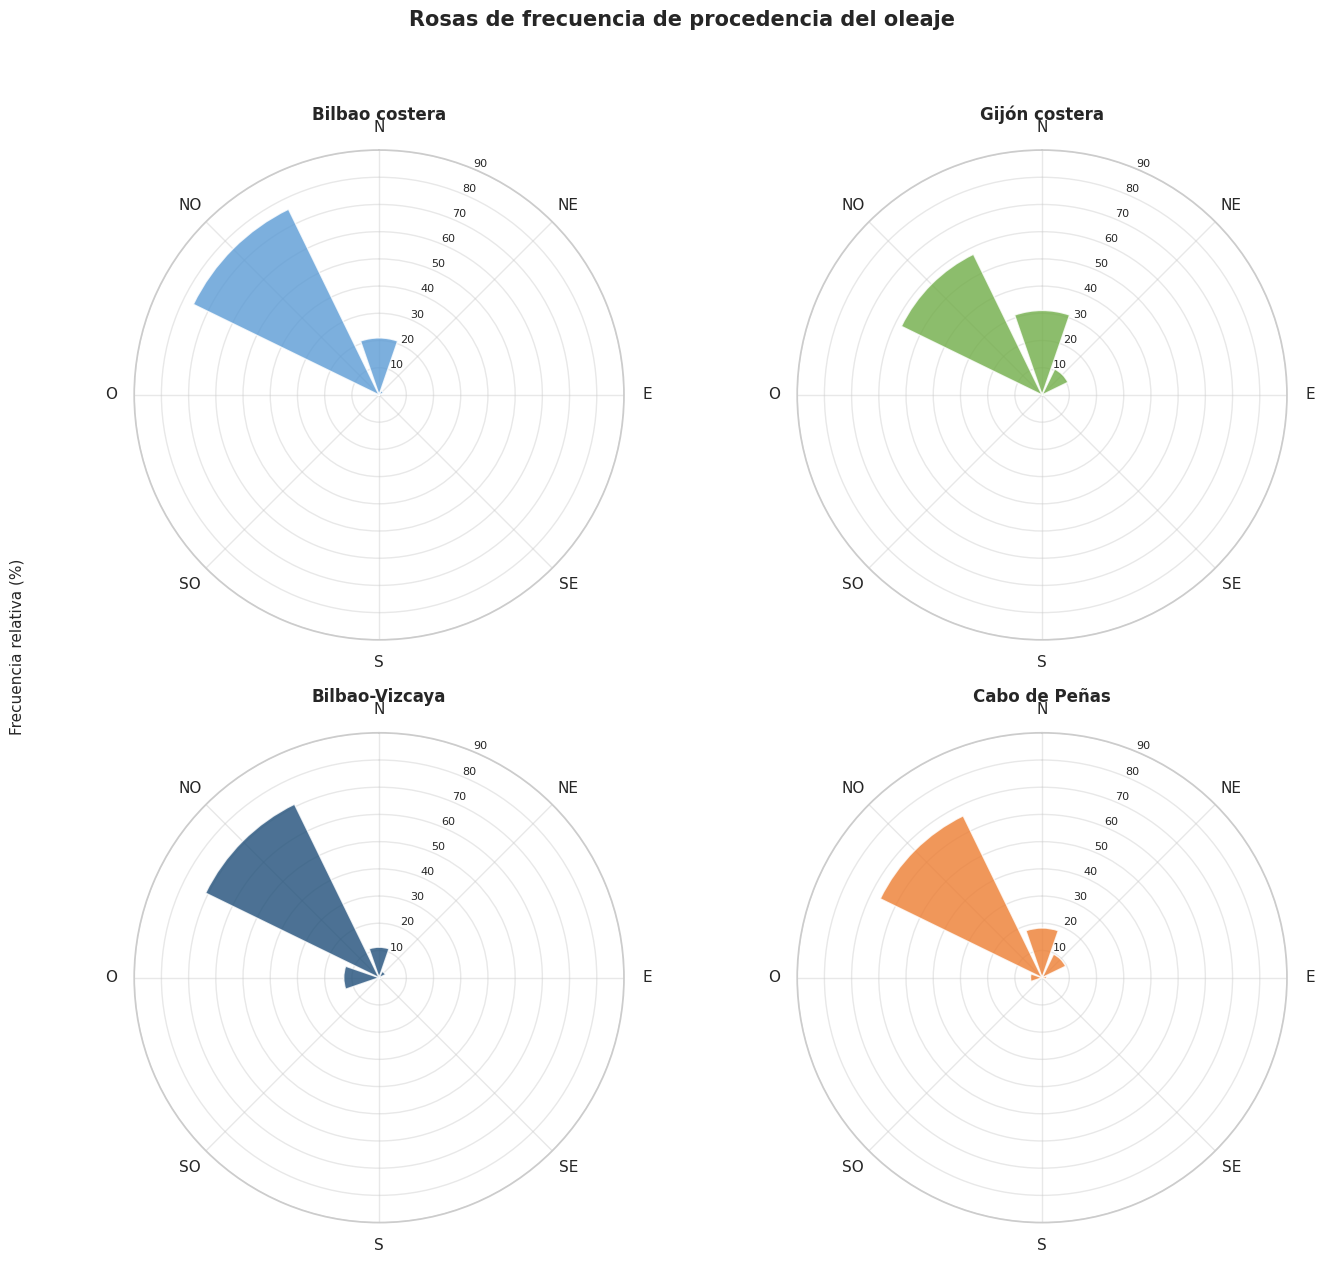

Figura guardada correctamente:
/content/figures/rosa_oleaje_por_boya.png


In [55]:
orden_boyas = [
    "Bilbao costera",
    "Gijón costera",
    "Bilbao-Vizcaya",
    "Cabo de Peñas"
]

colores_boya = {
    "Bilbao costera": "#5B9BD5",
    "Gijón costera": "#70AD47",
    "Bilbao-Vizcaya": "#1F4E79",
    "Cabo de Peñas": "#ED7D31"
}

# Calcular el máximo global de frecuencia
maximo_frecuencia = (
    tabla_frecuencia_direccional["frecuencia_pct"].max()
)

# Redondear hacia arriba al siguiente múltiplo de 10
limite_frecuencia = int(
    np.ceil(maximo_frecuencia / 10) * 10
)

# Añadir un margen de 10 puntos porcentuales
limite_frecuencia = limite_frecuencia + 10

# Crear marcas comunes para las cuatro rosas
marcas_frecuencia = np.arange(
    10,
    limite_frecuencia + 1,
    10
)

print(
    "Escala común de las rosas:",
    0,
    "-",
    limite_frecuencia,
    "%"
)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 13),
    subplot_kw={
        "projection": "polar"
    }
)

axes = axes.flatten()

for ax, nombre_boya in zip(
    axes,
    orden_boyas
):

    datos_boya = (
        tabla_frecuencia_direccional[
            tabla_frecuencia_direccional[
                "nombre_boya"
            ] == nombre_boya
        ]
        .set_index(
            "sector_direccion_media"
        )
        .reindex(orden_sectores)
    )

    frecuencias = (
        datos_boya["frecuencia_pct"]
        .fillna(0)
        .to_numpy()
    )

    ax.bar(
        angulos_radianes,
        frecuencias,
        width=ancho_barras,
        color=colores_boya[nombre_boya],
        alpha=0.80,
        edgecolor="white",
        linewidth=1
    )

    # Configuración direccional
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

    ax.set_xticks(angulos_radianes)
    ax.set_xticklabels(orden_sectores)

    # MISMA ESCALA EN LAS CUATRO ROSAS
    ax.set_ylim(
        0,
        limite_frecuencia
    )

    ax.set_yticks(
        marcas_frecuencia
    )

    ax.set_yticklabels(
        [
            str(valor)
            for valor in marcas_frecuencia
        ],
        fontsize=8
    )

    ax.set_rlabel_position(22.5)

    ax.set_title(
        nombre_boya,
        fontsize=12,
        fontweight="bold",
        pad=22
    )

    ax.grid(
        alpha=0.45
    )

fig.suptitle(
    "Rosas de frecuencia de procedencia del oleaje",
    fontsize=15,
    fontweight="bold",
    y=0.99
)

# Etiqueta común de la unidad
fig.text(
    0.02,
    0.50,
    "Frecuencia relativa (%)",
    rotation=90,
    va="center",
    fontsize=11
)

plt.tight_layout(
    rect=[0.04, 0.02, 1, 0.96]
)

ruta_rosa_oleaje = (
    FIGURES_DIR /
    "rosa_oleaje_por_boya.png"
)

plt.savefig(
    ruta_rosa_oleaje,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figura guardada correctamente:")
print(ruta_rosa_oleaje)

Creación de rosas de P95 de Hs

Escala común de P95: 0 - 6 m


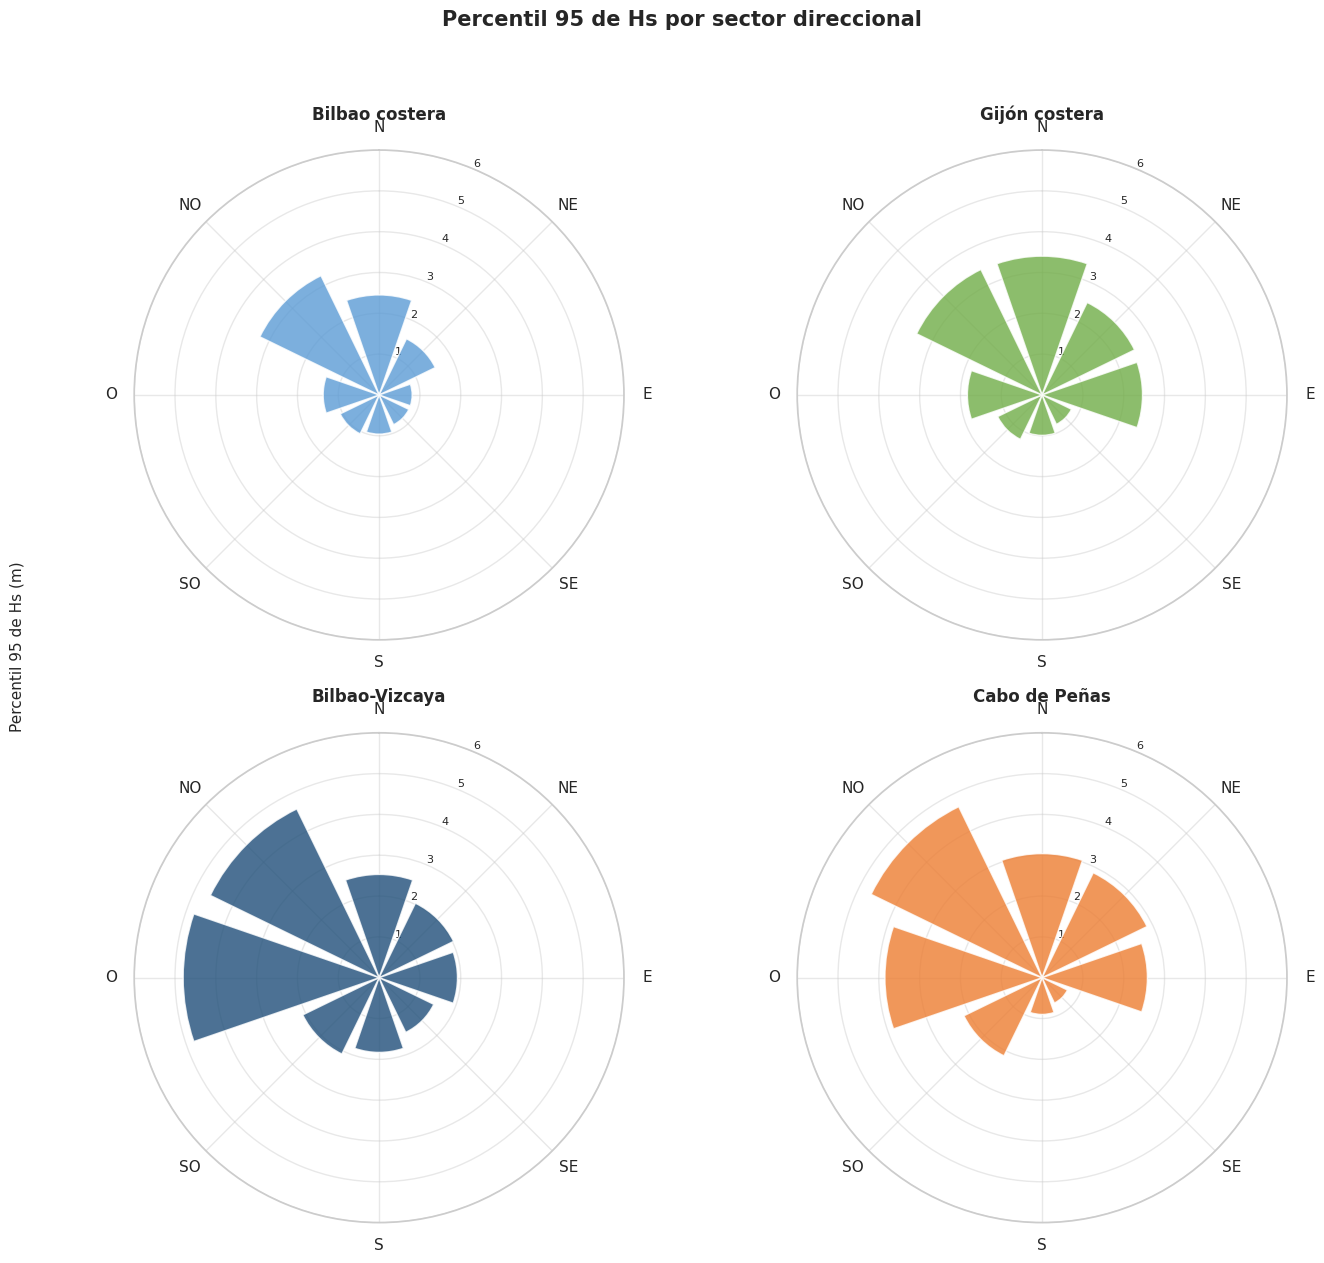

Figura guardada correctamente:
/content/figures/rosa_percentil95_hs_por_boya.png


In [56]:
# Calcular el máximo global del P95
maximo_p95 = (
    tabla_hs_por_sector["Hs_p95_m"].max()
)

# Redondear hacia arriba al entero siguiente
limite_p95 = int(
    np.ceil(maximo_p95)
)

# Añadir un metro de margen
limite_p95 = limite_p95 + 1

# Marcas radiales comunes
marcas_p95 = np.arange(
    1,
    limite_p95 + 1,
    1
)

print(
    "Escala común de P95:",
    0,
    "-",
    limite_p95,
    "m"
)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 13),
    subplot_kw={
        "projection": "polar"
    }
)

axes = axes.flatten()

for ax, nombre_boya in zip(
    axes,
    orden_boyas
):

    datos_boya = (
        tabla_hs_por_sector[
            tabla_hs_por_sector[
                "nombre_boya"
            ] == nombre_boya
        ]
        .set_index(
            "sector_direccion_media"
        )
        .reindex(orden_sectores)
    )

    valores_p95 = (
        datos_boya["Hs_p95_m"]
        .fillna(0)
        .to_numpy()
    )

    ax.bar(
        angulos_radianes,
        valores_p95,
        width=ancho_barras,
        color=colores_boya[nombre_boya],
        alpha=0.80,
        edgecolor="white",
        linewidth=1
    )

    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

    ax.set_xticks(angulos_radianes)
    ax.set_xticklabels(orden_sectores)

    # MISMA ESCALA EN LAS CUATRO ROSAS
    ax.set_ylim(
        0,
        limite_p95
    )

    ax.set_yticks(
        marcas_p95
    )

    ax.set_yticklabels(
        [
            str(valor)
            for valor in marcas_p95
        ],
        fontsize=8
    )

    ax.set_rlabel_position(22.5)

    ax.set_title(
        nombre_boya,
        fontsize=12,
        fontweight="bold",
        pad=22
    )

    ax.grid(
        alpha=0.45
    )

fig.suptitle(
    "Percentil 95 de Hs por sector direccional",
    fontsize=15,
    fontweight="bold",
    y=0.99
)

fig.text(
    0.02,
    0.50,
    "Percentil 95 de Hs (m)",
    rotation=90,
    va="center",
    fontsize=11
)

plt.tight_layout(
    rect=[0.04, 0.02, 1, 0.96]
)

ruta_rosa_p95 = (
    FIGURES_DIR /
    "rosa_percentil95_hs_por_boya.png"
)

plt.savefig(
    ruta_rosa_p95,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figura guardada correctamente:")
print(ruta_rosa_p95)

RESUMEN

In [48]:
print("RESUMEN DEL ANÁLISIS DIRECCIONAL")
print("=" * 65)

for _, fila in tabla_sectores_dominantes.iterrows():

    print()
    print(
        fila["nombre_boya"],
        "(" + fila["tipo_boya"] + ")"
    )

    print(
        "- Sector más frecuente:",
        fila["sector_mas_frecuente"],
        "-",
        fila["frecuencia_sector_pct"],
        "%"
    )

    print(
        "- Sector con mayor Hs media:",
        fila["sector_mayor_Hs_media"],
        "-",
        fila["mayor_Hs_media_m"],
        "m"
    )

    print(
        "- Sector con mayor P95:",
        fila["sector_mayor_P95"],
        "-",
        fila["mayor_P95_m"],
        "m"
    )

RESUMEN DEL ANÁLISIS DIRECCIONAL

Bilbao costera (Costera)
- Sector más frecuente: NO - 75.95 %
- Sector con mayor Hs media: NO - 1.53 m
- Sector con mayor P95: NO - 3.25 m

Gijón costera (Costera)
- Sector más frecuente: NO - 57.54 %
- Sector con mayor Hs media: NO - 1.73 m
- Sector con mayor P95: NO - 3.42 m

Bilbao-Vizcaya (Exterior)
- Sector más frecuente: NO - 70.95 %
- Sector con mayor Hs media: O - 2.25 m
- Sector con mayor P95: O - 4.8 m

Cabo de Peñas (Exterior)
- Sector más frecuente: NO - 66.18 %
- Sector con mayor Hs media: NO - 2.21 m
- Sector con mayor P95: NO - 4.66 m


## 5. Interpretación de los resultados

El análisis direccional permite diferenciar entre la procedencia más frecuente del oleaje y los sectores asociados a una mayor intensidad.

El sector dominante se obtiene a partir de la frecuencia relativa de observaciones. Sin embargo, el sector más frecuente no tiene por qué coincidir con el sector que presenta la mayor Hs media o el mayor percentil 95.

Esta diferencia es relevante para la gestión portuaria. Un sector puede dominar el clima marítimo habitual, mientras que otro sector menos frecuente puede concentrar las condiciones más elevadas.

Las diferencias entre boyas reflejan su localización y grado de exposición. No deben interpretarse como una clasificación entre puertos ni como una representación directa del oleaje en el interior de las instalaciones portuarias.

Los registros con Hs igual o superior a 3 m permiten estudiar la procedencia asociada a condiciones elevadas. Esta información puede utilizarse para seleccionar episodios, apoyar la vigilancia marítima y contextualizar la planificación de operaciones sensibles.

Para trasladar directamente estos resultados a una dársena o atraque sería necesario combinar los datos de las boyas con información sobre batimetría, orientación de la costa y bocanas, modelos de propagación y registros de agitación interior.

## Conclusiones del análisis direccional

El análisis ha permitido clasificar las direcciones medias del oleaje en ocho sectores y calcular indicadores de frecuencia e intensidad para cada boya.

La cobertura direccional es suficientemente elevada para desarrollar el análisis, aunque los registros sin dirección válida se han excluido y no se han imputado.

Las rosas de oleaje muestran la distribución relativa de las procedencias observadas. Los indicadores de Hs media y P95 permiten añadir una dimensión de intensidad a la información direccional.

La identificación del sector más frecuente, el sector con mayor Hs media y el sector con mayor P95 demuestra que la frecuencia y la severidad son dimensiones diferentes del clima marítimo.

Desde la perspectiva de la gestión portuaria, estos resultados pueden utilizarse para contextualizar condiciones marítimas, identificar direcciones asociadas a oleaje elevado y seleccionar situaciones que requieran un análisis más detallado.



Exportación de tablas e imágenes

In [58]:
print("TABLAS GENERADAS")
print("-" * 60)

for archivo in sorted(
    os.listdir(TABLES_DIR)
):
    ruta = TABLES_DIR / archivo
    tamano_kb = (
        ruta.stat().st_size / 1024
    )

    print(
        archivo,
        "-",
        round(tamano_kb, 2),
        "KB"
    )

TABLAS GENERADAS
------------------------------------------------------------
tabla_calidad_direccion_oleaje.csv - 0.39 KB
tabla_direccion_hs_ge_3m.csv - 1.23 KB
tabla_frecuencia_direccional.csv - 1.64 KB
tabla_hs_por_sector_direccional.csv - 2.07 KB
tabla_percentil95_por_direccion.csv - 1.41 KB
tabla_sectores_dominantes.csv - 0.41 KB


Figuras

In [59]:
print("FIGURAS GENERADAS")
print("-" * 60)

for archivo in sorted(
    os.listdir(FIGURES_DIR)
):
    ruta = FIGURES_DIR / archivo
    tamano_kb = (
        ruta.stat().st_size / 1024
    )

    print(
        archivo,
        "-",
        round(tamano_kb, 2),
        "KB"
    )

FIGURAS GENERADAS
------------------------------------------------------------
direccion_oleaje_hs_ge_3m.png - 159.44 KB
frecuencia_direccion_por_boya.png - 150.59 KB
hs_media_por_sector_direccional.png - 133.61 KB
percentil95_hs_por_sector.png - 133.12 KB
rosa_oleaje_por_boya.png - 799.84 KB
rosa_percentil95_hs_por_boya.png - 824.17 KB


Descarga figuras y tablas generadas

In [60]:
shutil.make_archive(
    "/content/tablas_notebook_05",
    "zip",
    TABLES_DIR
)

shutil.make_archive(
    "/content/figuras_notebook_05",
    "zip",
    FIGURES_DIR
)

print("Archivos ZIP creados correctamente.")
print("/content/tablas_notebook_05.zip")
print("/content/figuras_notebook_05.zip")

Archivos ZIP creados correctamente.
/content/tablas_notebook_05.zip
/content/figuras_notebook_05.zip


In [61]:
from google.colab import files

files.download(
    "/content/tablas_notebook_05.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [62]:
files.download(
    "/content/figuras_notebook_05.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>